In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. 
# Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 
# To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. 
# It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

print('-- inputs X ---')
print(X)
print("X shape=",X.shape)

print('-- outputs y ---')
print(y)
print("y shape=",y.shape)

-- inputs X ---
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]
X shape= (10, 2)
-- outputs y ---
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522]
y shape= (10,)


In [2]:
df = pd.DataFrame(X, columns=["x1","x2"])
df['y'] = y

df = df.sort_values(by='y', ascending=False)
df

,x1,x2,y
9,0.702637,0.926564,0.611205
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
3,0.845275,0.711120,0.293993
6,0.438166,0.685018,0.244619
4,0.454647,0.290455,0.214965
7,0.341750,0.028698,0.038749
5,0.577713,0.771973,0.023106
8,0.338648,0.213867,-0.013858
2,0.142699,0.349005,-0.065624


In [32]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)


kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5, 0.5], 
                                      length_scale_bounds=(1e-3, 1e5), 
                                      nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.2, normalize_y=True, n_restarts_optimizer=10)


gp.fit(X, y)

print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y)}")
print(f"Total variance accounted for as noise: {gp.alpha}")

# Optimized Kernel: 0.936**2 * Matern(length_scale=[0.0643, 6.35e+04], nu=2.5)
# Training R^2 Score: 0.9665465591169711
# Total variance accounted for as noise: 0.2

Optimized Kernel: 0.936**2 * Matern(length_scale=[0.0643, 6.35e+04], nu=2.5)
Training R^2 Score: 0.9665465591169711
Total variance accounted for as noise: 0.2


In [14]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + kappa * sigma
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Predict
X_grid = np.random.uniform(0, 1, size=(10000, 2))
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)
y_best = y.max()

In [15]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"expected_improvement with xi: {xi}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ei_next_query}")

# best combination so far 
#     x1      x2          y
# 0.702637	0.926564	0.611205
# Suggested next: 
#     x1          x2  
# [0.95959596 1.        ]

expected_improvement with xi: 0.01
Current Best y: 0.6112052157614438
Suggested next: [0.72270309 0.41672885]


In [16]:
# kappa = 2.0 is a great starting point for week 1
kappa=2.0
ucb_values = upper_confidence_bound(mu, sigma, kappa)

# ucb_map = ucb_values.reshape(res, res)
# mu_map = mu.reshape(res, res)

ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"UCB Score with kappa: {kappa}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ucb_next_query}")

# best combination so far 
#     x1      x2          y
# 0.702637	0.926564	0.611205
# Suggested next: 
#     x1          x2         
# [0.96969697 0.93939394]

# Submit UCB

UCB Score with kappa: 2.0
Current Best y: 0.6112052157614438
Suggested next: [0.73780378 0.60155542]


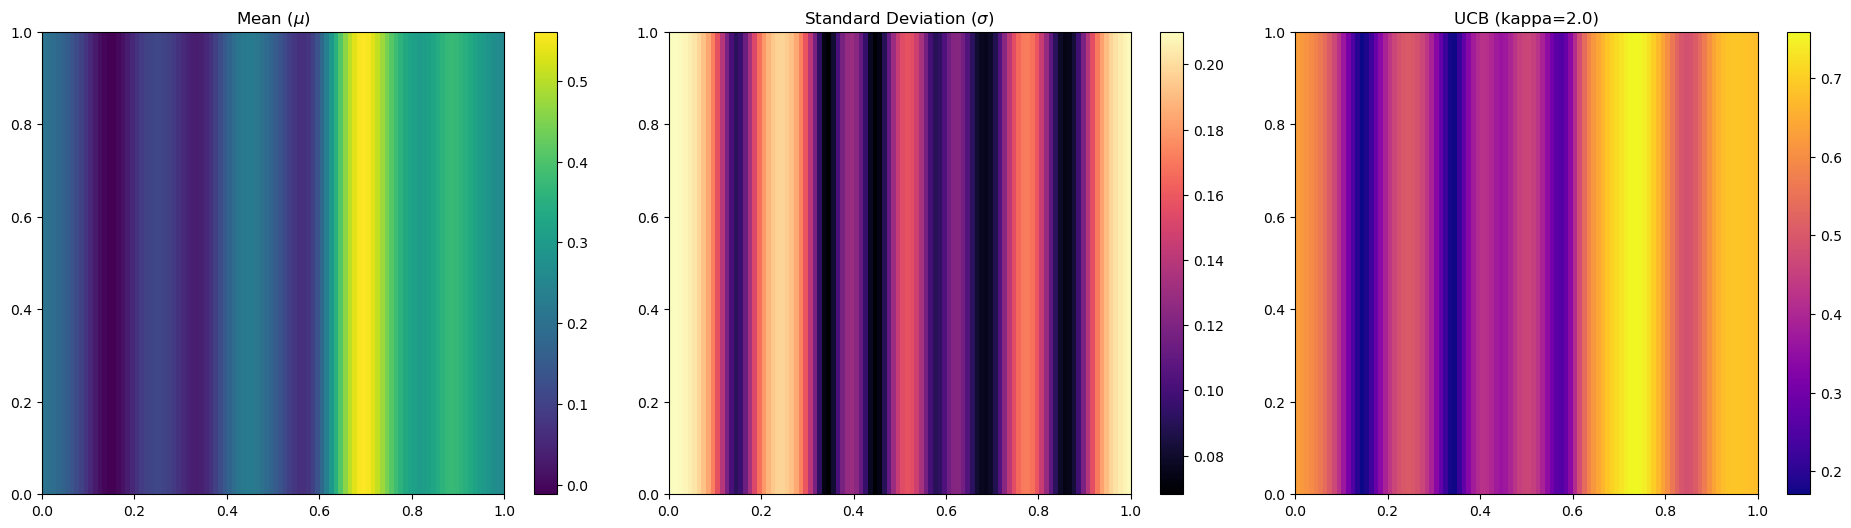

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a structured grid for plotting (e.g., 100x100)
res = 100
x1 = np.linspace(0, 1, res)
x2 = np.linspace(0, 1, res)
X1, X2 = np.meshgrid(x1, x2)
X_plot = np.vstack([X1.ravel(), X2.ravel()]).T

# 2. Predict on the structured grid
mu, sigma = gp.predict(X_plot, return_std=True)
ucb_values = upper_confidence_bound(mu, sigma, kappa=2.0)

# 3. Reshape values back to the grid shape
mu_map = mu.reshape(res, res)
sigma_map = sigma.reshape(res, res)
ucb_map = ucb_values.reshape(res, res)

# 4. Plotting
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Mean Plot
im1 = axes[0].imshow(mu_map, origin='lower', extent=[0, 1, 0, 1], cmap='viridis')
axes[0].set_title('Mean ($\mu$)')
fig.colorbar(im1, ax=axes[0])

# Sigma Plot (Uncertainty)
im2 = axes[1].imshow(sigma_map, origin='lower', extent=[0, 1, 0, 1], cmap='magma')
axes[1].set_title('Standard Deviation ($\sigma$)')
fig.colorbar(im2, ax=axes[1])

# UCB Plot
im3 = axes[2].imshow(ucb_map, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
axes[2].set_title(f'UCB (kappa={kappa})')
fig.colorbar(im3, ax=axes[2])

# Optional: Plot the points you have already sampled
# axes[2].scatter(X_train[:, 0], X_train[:, 1], c='red', marker='x', label='Sampled')

plt.tight_layout()
plt.show()

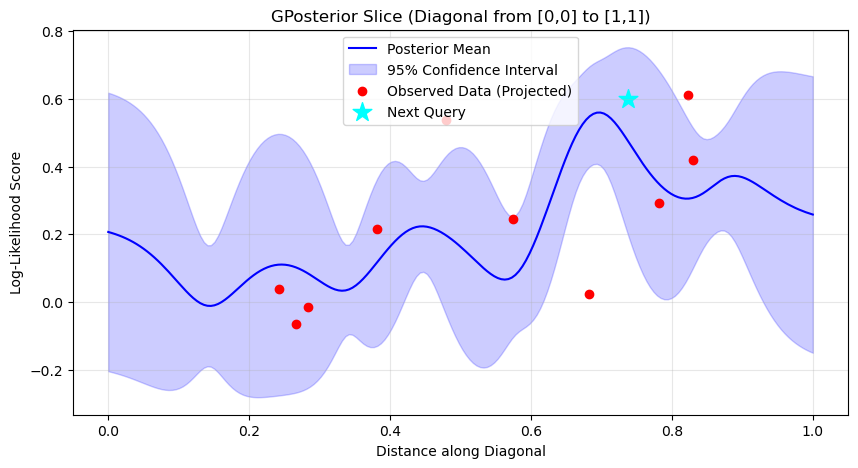

In [18]:
# Create a diagonal slice from [0,0] to [1,1]
n_points = 200
line_coords = np.linspace(0, 1, n_points)
X_slice = np.c_[line_coords, line_coords] # Diagonal slice

# Get mean and standard deviation from the Posterior
mu, sigma = gp.predict(X_slice, return_std=True)

plt.figure(figsize=(10, 5))

# Plot the Mean prediction
plt.plot(line_coords, mu, 'b-', label='Posterior Mean')

# Plot the Confidence Interval (95% confidence = 1.96 * sigma)
plt.fill_between(line_coords, mu - 1.96*sigma, mu + 1.96*sigma, 
                 alpha=0.2, color='blue', label='95% Confidence Interval')

# Project existing data points onto this diagonal (for visualization)
# We calculate their distance from [0,0] to place them on the X-axis
dist = np.sqrt(np.sum(X**2, axis=1)) / np.sqrt(2)
plt.scatter(dist, y, c='red', label='Observed Data (Projected)')
plt.scatter(next_query[0], next_query[1], c='cyan', marker='*', s=200, label='Next Query')


plt.title('GPosterior Slice (Diagonal from [0,0] to [1,1])')
plt.xlabel('Distance along Diagonal')
plt.ylabel('Log-Likelihood Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

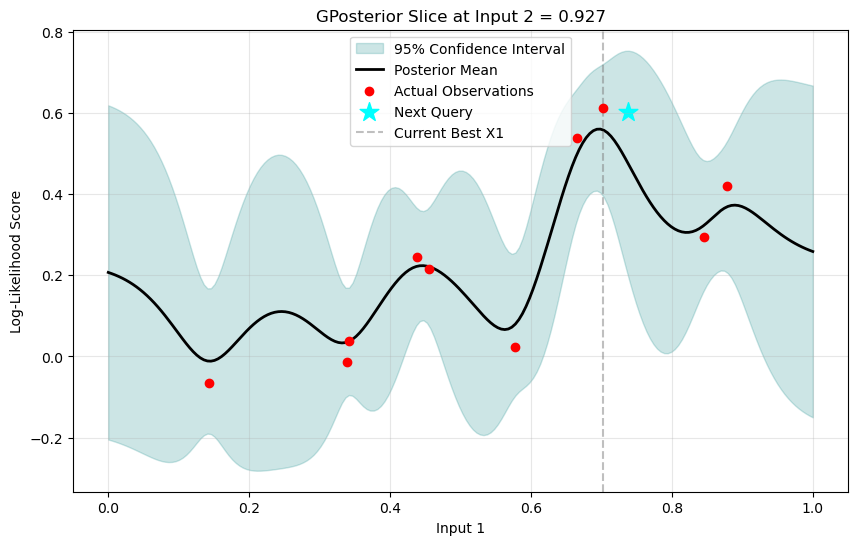

In [19]:
x1_range = np.linspace(0, 1, 200)
fixed_x2 = 0.9265642  # Your best y-coordinate so far
X_slice = np.c_[x1_range, np.full_like(x1_range, fixed_x2)]

# 3. Get Posterior Mean and Standard Deviation
mu, sigma = gp.predict(X_slice, return_std=True)

# 4. Plot
plt.figure(figsize=(10, 6))

# The 95% confidence interval (Posterior Uncertainty)
plt.fill_between(x1_range, mu - 1.96*sigma, mu + 1.96*sigma, 
                 alpha=0.2, color='teal', label='95% Confidence Interval')

# The Mean prediction (The "Best Guess")
plt.plot(x1_range, mu, 'k-', lw=2, label='Posterior Mean')

# Plot the actual data points that are "near" this slice
# (We color them by how close they are to the fixed_x2 for clarity)
plt.scatter(X[:, 0], y, c='red', zorder=5, label='Actual Observations')
plt.scatter(next_query[0], next_query[1], c='cyan', marker='*', s=200, label='Next Query')

plt.axvline(x=0.702, color='grey', linestyle='--', alpha=0.5, label='Current Best X1')
plt.title(f'GPosterior Slice at Input 2 = {fixed_x2:.3f}')
plt.xlabel('Input 1')
plt.ylabel('Log-Likelihood Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()